In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import  EarlyStopping,ReduceLROnPlateau

In [9]:
(x_train,y_train,),(x_test,y_test)=keras.datasets.mnist.load_data()
print("Train images :", x_train.shape, "| Labels :", y_train.shape)
print("Test  images :", x_test.shape,  "| Labels :", y_test.shape)
print("Pixel range  :", x_train.min(), "-", x_train.max())
print("Classes      :", np.unique(y_train))


Train images : (60000, 28, 28) | Labels : (60000,)
Test  images : (10000, 28, 28) | Labels : (10000,)
Pixel range  : 0 - 255
Classes      : [0 1 2 3 4 5 6 7 8 9]


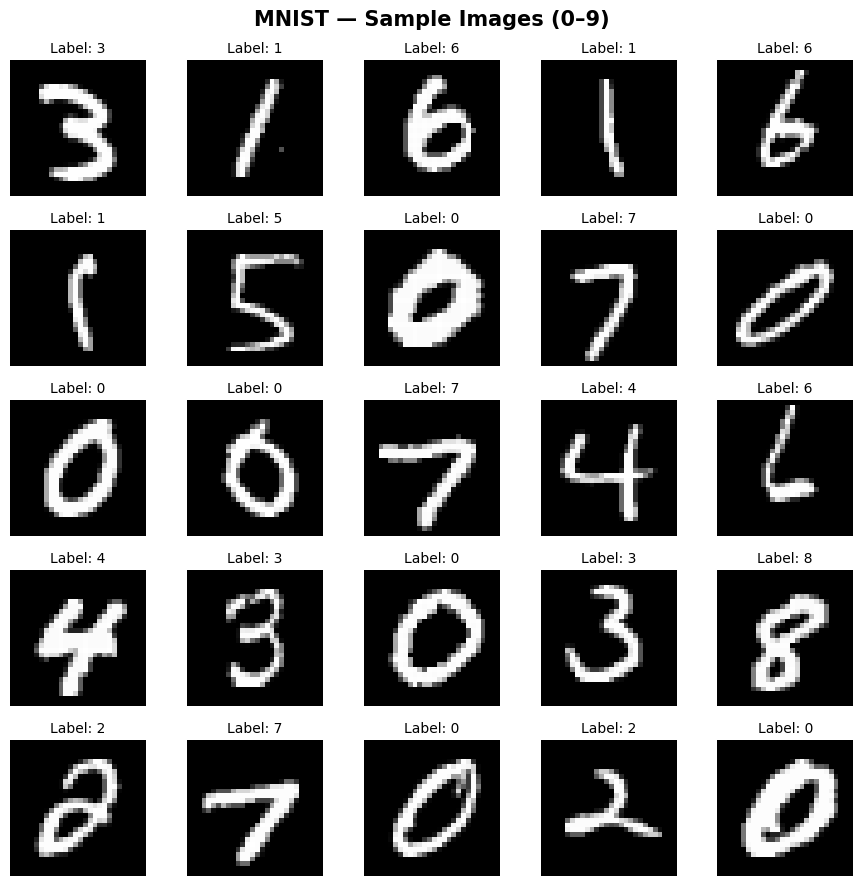

In [11]:
fig, axes = plt.subplots(5, 5, figsize=(9, 9))
fig.suptitle('MNIST — Sample Images (0–9)', fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(x_train))
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(f'Label: {y_train[idx]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

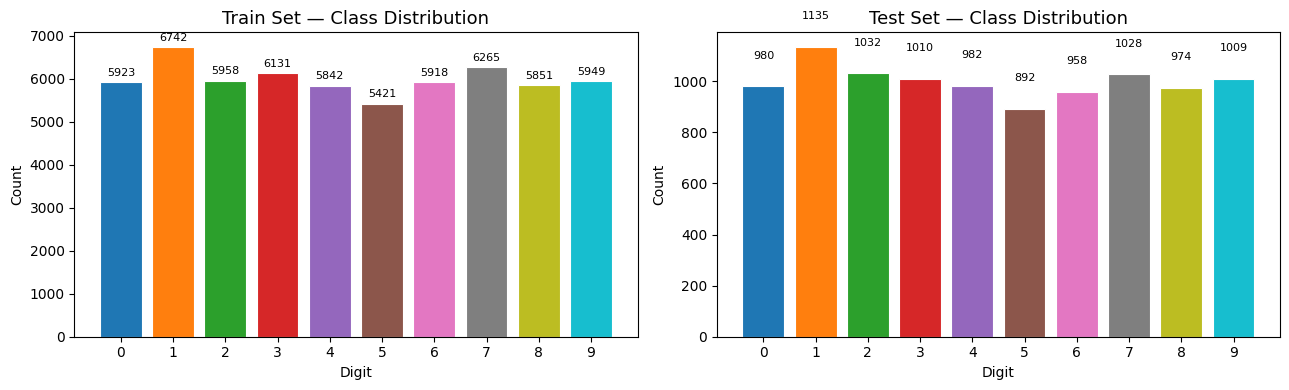

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (data, name) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    unique, counts = np.unique(data, return_counts=True)
    bars = ax.bar(unique, counts, color=plt.cm.tab10(unique / 10.0),
                  edgecolor='white', linewidth=0.8)
    ax.set_title(f'{name} Set — Class Distribution', fontsize=13)
    ax.set_xlabel('Digit'); ax.set_ylabel('Count')
    ax.set_xticks(unique)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100, str(cnt),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# 1. Normalize: 0-255  →  0.0-1.0
x_train_n = x_train.astype('float32') / 255.0
x_test_n  = x_test.astype('float32')  / 255.0

# 2. Reshape: (28,28) → (28,28,1)  — CNN ko channel dimension chahiye
x_train_n = x_train_n.reshape(-1, 28, 28, 1)
x_test_n  = x_test_n.reshape(-1, 28, 28, 1)

# 3. One-Hot Encode labels: 5 → [0,0,0,0,0,1,0,0,0,0]
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test,  10)

print("x_train shape :", x_train_n.shape)
print("x_test  shape :", x_test_n.shape)
print("y_train shape :", y_train_oh.shape,  "← One-Hot")
print("Pixel range   :", x_train_n.min(), "-", x_train_n.max())



x_train shape : (60000, 28, 28, 1)
x_test  shape : (10000, 28, 28, 1)
y_train shape : (60000, 10) ← One-Hot
Pixel range   : 0.0 - 1.0
✅ Preprocessing done!


In [16]:
model = keras.Sequential([

    # ── Block 1 ─────────────────────────────
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # ── Block 2 ─────────────────────────────
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # ── Classifier Head ─────────────────────
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # 10 classes (0–9)
], name='MNIST_CNN')

model.summary()


Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

print("✅ Model compiled!")
print("Optimizer : Adam (lr=0.001)")
print("Loss      : Categorical Crossentropy")
print("Metrics   : Accuracy")


✅ Model compiled!
Optimizer : Adam (lr=0.001)
Loss      : Categorical Crossentropy
Metrics   : Accuracy


In [19]:
history = model.fit(
    x_train_n, y_train_oh,
    epochs=20,
    batch_size=128,
    validation_split=0.1,       # 10% validation
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training complete!")
print(f"Best Val Accuracy: {max(history.history['val_accuracy']):.4f}")


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 93s 201ms/step - accuracy: 0.9377 - loss: 0.2035 - val_accuracy: 0.4403 - val_loss: 1.6920 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 85s 203ms/step - accuracy: 0.9796 - loss: 0.0658 - val_accuracy: 0.9905 - val_loss: 0.0356 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 193ms/step - accuracy: 0.9835 - loss: 0.0528 - val_accuracy: 0.9903 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 191ms/step - accuracy: 0.9870 - loss: 0.0417 - val_accuracy: 0.9903 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 198ms/step - accuracy: 0.9887 - loss: 0.0363 - val_accuracy: 0.9918 - val_loss: 0.0289 - learning_rate: 0.0010
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 106s 251ms/step - accuracy: 0.9901 - loss: 0.0323 - val_accuracy: 0.9915 - val_loss: 0.0259 - learning_rate: 0.0010
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 138s 212ms/step - accuracy: 0

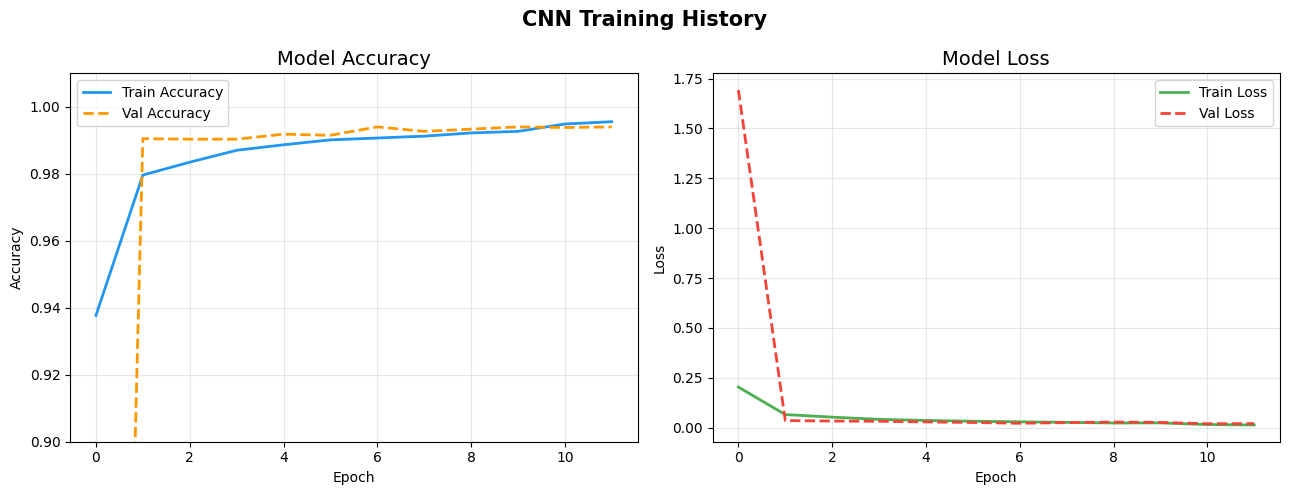

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#2196F3', lw=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#FF9800', lw=2, linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim([0.9, 1.01])

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='#4CAF50', lw=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#F44336', lw=2, linestyle='--')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('CNN Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
test_loss, test_acc = model.evaluate(x_test_n, y_test_oh, verbose=0)

print("=" * 40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("=" * 40)


  Test Loss     : 0.0234
  Test Accuracy : 0.9921  (99.21%)


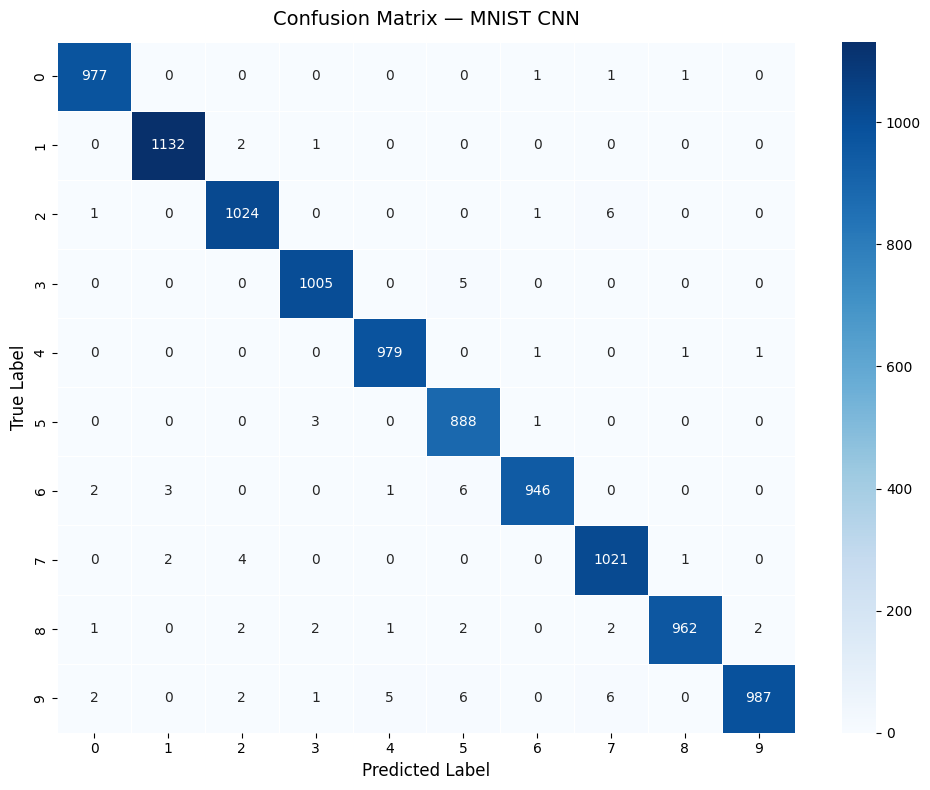


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      1.00      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [23]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(x_test_n, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5)
plt.title('Confusion Matrix — MNIST CNN', fontsize=14, pad=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Total wrong predictions: 79 / 10000


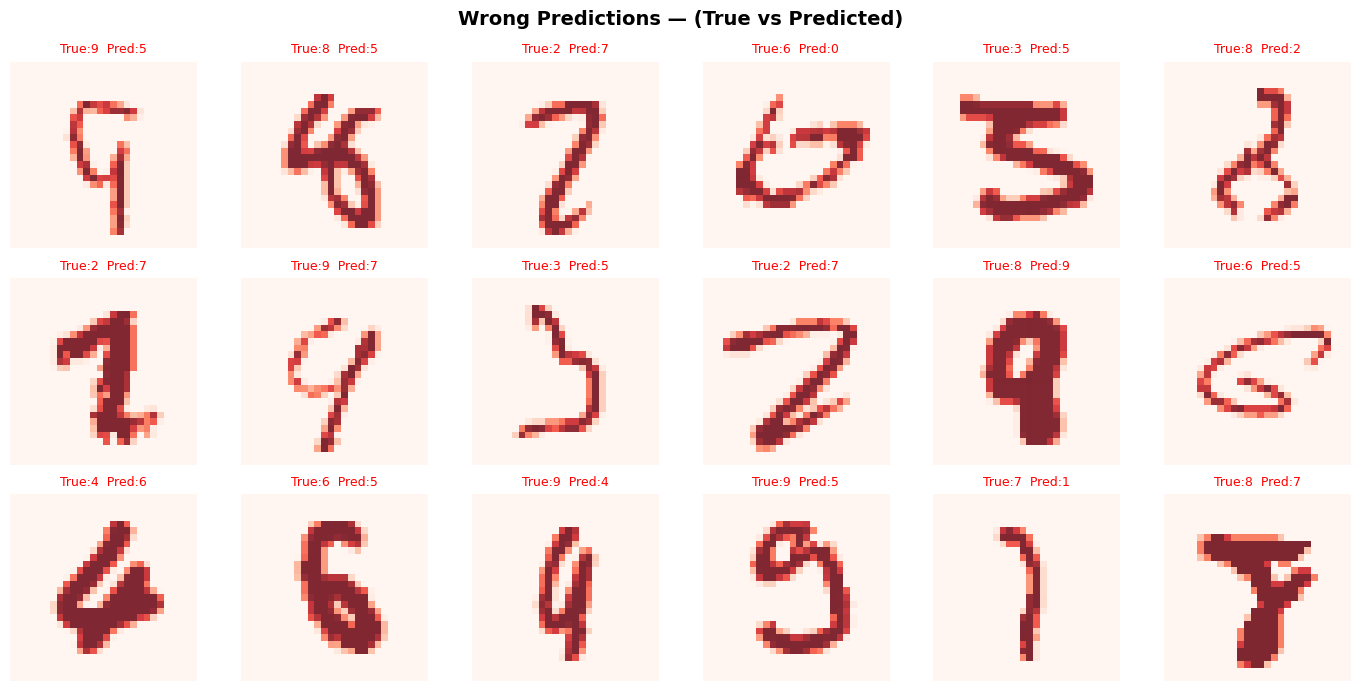

In [25]:
# Jinhe model galat classify kiya
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Total wrong predictions: {len(wrong_idx)} / {len(y_test)}")

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
fig.suptitle('Wrong Predictions — (True vs Predicted)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= len(wrong_idx):
        ax.axis('off'); continue
    idx = wrong_idx[i]
    ax.imshow(x_test[idx], cmap='Reds', alpha=0.85)
    ax.set_title(f'True:{y_test[idx]}  Pred:{y_pred[idx]}',
                 fontsize=9, color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('wrong_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


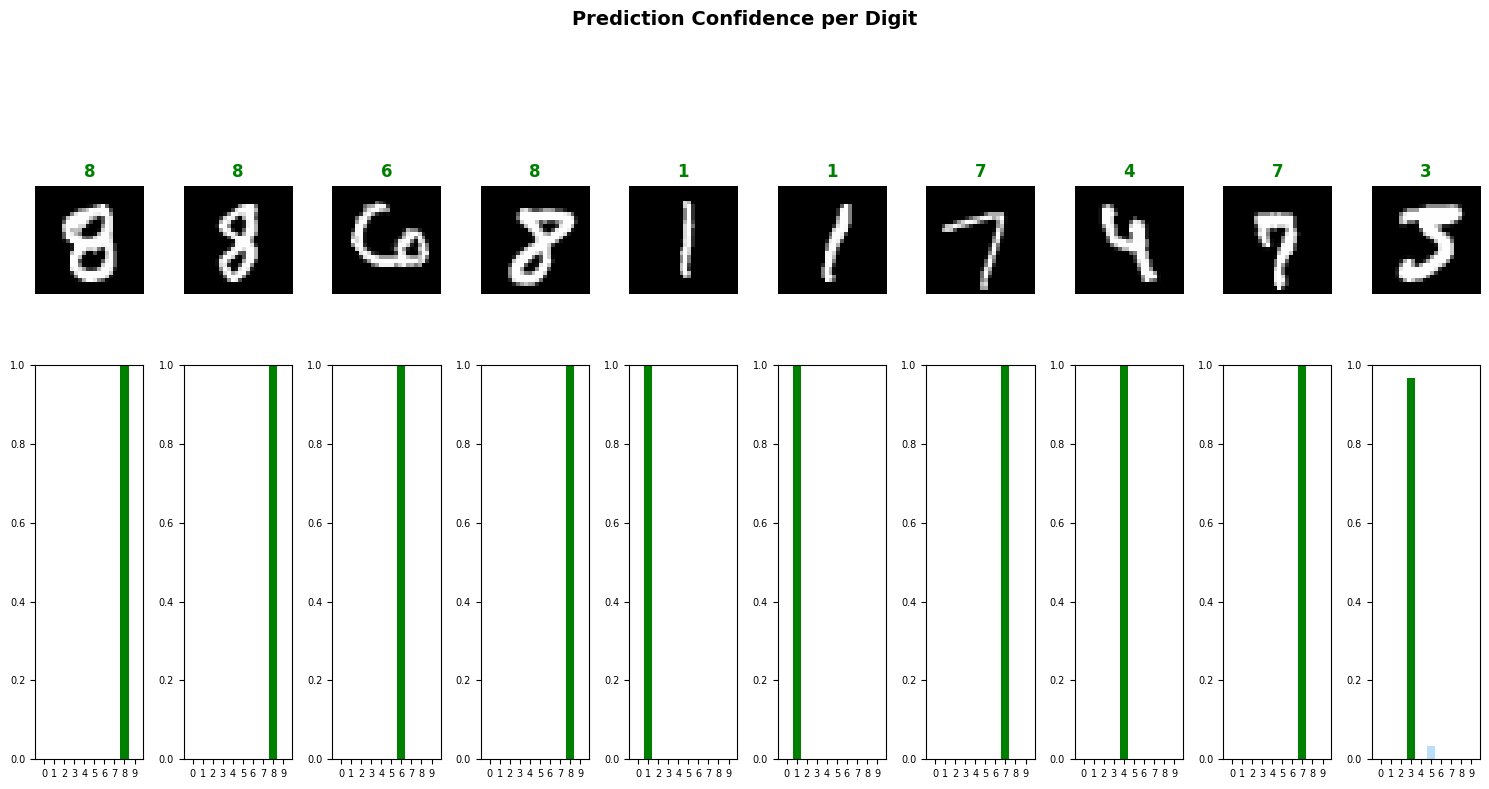

In [28]:
# 10 random test images ke saath confidence bars
fig = plt.figure(figsize=(15, 8))
fig.suptitle('Prediction Confidence per Digit', fontsize=14, fontweight='bold')

indices = np.random.choice(len(x_test), 10, replace=False)
for plot_i, idx in enumerate(indices):
    img     = x_test_n[idx]
    true_lbl = y_test[idx]
    probs    = y_pred_prob[idx]
    pred_lbl = np.argmax(probs)

    ax_img = fig.add_subplot(2, 10, plot_i + 1)
    ax_img.imshow(img.squeeze(), cmap='gray')
    color = 'green' if pred_lbl == true_lbl else 'red'
    ax_img.set_title(f'{pred_lbl}', color=color, fontsize=12, fontweight='bold')
    ax_img.axis('off')

    ax_bar = fig.add_subplot(2, 10, plot_i + 11)
    bar_colors = ['green' if i == pred_lbl else
                  'red'   if i == true_lbl  else '#BBDEFB'
                  for i in range(10)]
    ax_bar.bar(range(10), probs, color=bar_colors)
    ax_bar.set_xticks(range(10)); ax_bar.set_ylim(0, 1)
    ax_bar.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('confidence_scores.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
# .keras format (recommended for TF 2.x)
model.save('mnist_cnn_model.keras')
print("✅ Model saved: mnist_cnn_model.keras")

# Load back & verify
loaded_model = keras.models.load_model('mnist_cnn_model.keras')
_, acc = loaded_model.evaluate(x_test_n, y_test_oh, verbose=0)
print(f"✅ Loaded model accuracy: {acc*100:.2f}%")


✅ Model saved: mnist_cnn_model.keras
✅ Loaded model accuracy: 99.21%


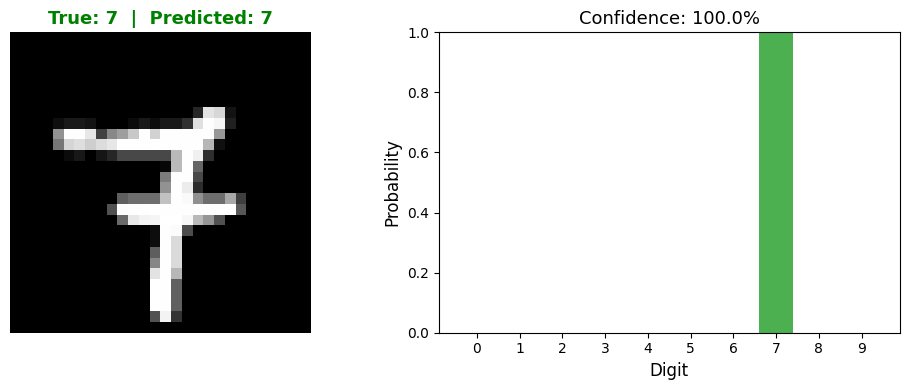

Predicted: 7  |  True: 7  |  Confidence: 100.0%


In [32]:
# Test set se ek image uthao aur predict karo
sample_idx = np.random.randint(0, len(x_test))
sample_img = x_test_n[sample_idx]
true_label = y_test[sample_idx]

# Model ko (1,28,28,1) shape chahiye
pred_probs = model.predict(sample_img.reshape(1, 28, 28, 1), verbose=0)[0]
pred_label = np.argmax(pred_probs)
confidence = pred_probs[pred_label] * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(sample_img.squeeze(), cmap='gray')
color = 'green' if pred_label == true_label else 'red'
axes[0].set_title(f'True: {true_label}  |  Predicted: {pred_label}',
                  color=color, fontsize=13, fontweight='bold')
axes[0].axis('off')

bar_cols = ['#4CAF50' if i == pred_label else '#BBDEFB' for i in range(10)]
axes[1].bar(range(10), pred_probs, color=bar_cols)
axes[1].set_xticks(range(10))
axes[1].set_xlabel('Digit', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_title(f'Confidence: {confidence:.1f}%', fontsize=13)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
print(f"Predicted: {pred_label}  |  True: {true_label}  |  Confidence: {confidence:.1f}%")
